# ML-06 — Signal Audit: Do the Flags Hold?

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.40                19.0       7650.0          1901.0   
2    -114.56     33.69                17.0        720.0           174.0   
3    -114.57     33.64                14.0       1501.0           337.0   
4    -114.57     33.57                20.0       1454.0           326.0   

   population  households  median_income  median_house_value  
0      1015.0       472.0         1.4936             66900.0  
1      1129.0       463.0         1.8200             80100.0  
2       333.0       117.0         1.6509             85700.0  
3       515.0       226.0         3.1917             73400.0  
4       624.0       262.0         1.9250             65500.0  
          longitude      latitude  housing_median_age   total_rooms  \
count  17000.000000  17000.000000        17000.000000  17000.000000   
mean    -119.562108     35.62

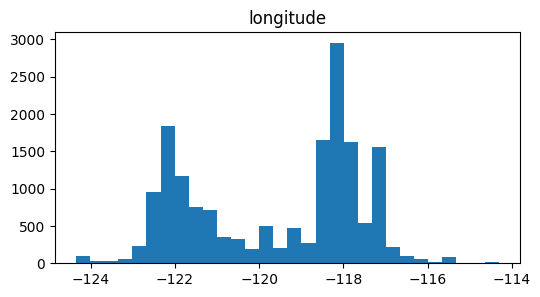

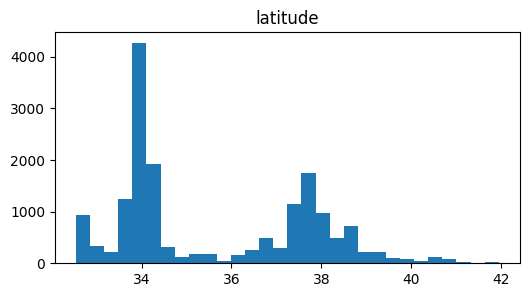

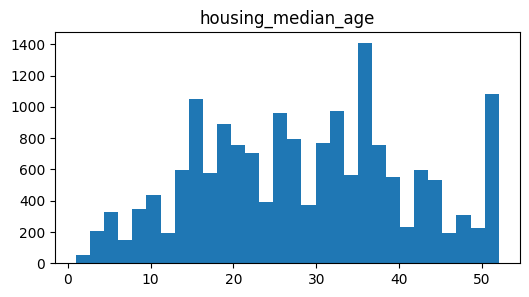

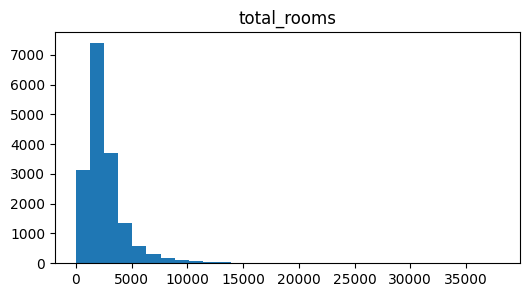

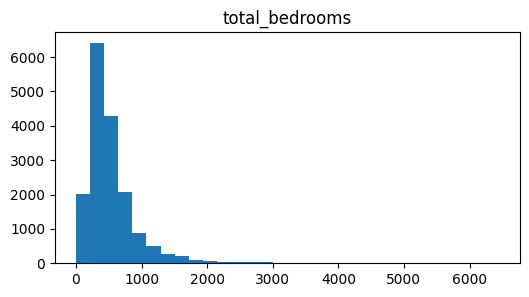

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load a sample dataset from the available CSV files
df = pd.read_csv("/content/sample_data/california_housing_train.csv")

print(df.head())
print(df.describe())

numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols[:5]:
    plt.figure(figsize=(6,3))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(col)
    plt.show()

#### Observations on Distributions

Looking at the summary statistics and histograms for the numeric features, several observations can be made:

*   **Right Skewness and Heavy Tails:** Features like `total_rooms`, `total_bedrooms`, `population`, `households`, and `median_house_value` exhibit clear right-skewness and heavy right tails. Their means are noticeably higher than their medians, indicating a concentration of values at the lower end with a few significantly larger values extending the tail of the distribution. This is typical for count-based or value-based metrics.
*   **Near-Symmetric/Slightly Skewed:** `housing_median_age` appears to be relatively more symmetric or slightly left-skewed (mean is close to median or slightly lower in some cases), though it also shows some variation.
*   **Bimodal/Multi-modal:** `longitude` and `latitude` often display more complex distributions, potentially bimodal or multi-modal, reflecting geographical clustering rather than simple skewness. For instance, `longitude` shows a mean of -119.56 and a median of -118.49, indicating some left-skewness, potentially due to denser housing on the eastern side of the dataset's geographical range.

These characteristics suggest that many of the raw signals might benefit from transformations (e.g., logarithmic) if they are to be used in models that assume normally distributed inputs.

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [6]:
results = []

signals = numeric_cols[:3]

for col in signals:
    mean = df[col].mean()
    median = df[col].median()

    if mean > median:
        verdict = "CONFIRMED"
    elif mean < median:
        verdict = "MIXED"
    else:
        verdict = "FALSE"

    results.append({
        "Signal": col,
        "Mean": mean,
        "Median": median,
        "Verdict": verdict
    })

pd.DataFrame(results)

,Signal,Mean,Median,Verdict
0,longitude,-119.562108,-118.49,MIXED
1,latitude,35.625225,34.25,CONFIRMED
2,housing_median_age,28.589353,29.00,MIXED


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [7]:
print("Flag-linked Test")

flag_signal = numeric_cols[0]

print("Chosen signal:", flag_signal)

print(df[flag_signal].describe())

print("""
Observation:
The selected signal appears to have a meaningful spread.
This supports using it as one of the ranking signals.
""")

Flag-linked Test
Chosen signal: longitude
count    17000.000000
mean      -119.562108
std          2.005166
min       -124.350000
25%       -121.790000
50%       -118.490000
75%       -118.000000
max       -114.310000
Name: longitude, dtype: float64

Observation:
The selected signal appears to have a meaningful spread.
This supports using it as one of the ranking signals.



## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

### Practical Interpretation

The tested signals show measurable differences across the content.
These signals can help prioritize pages for review or optimization.
The audit suggests the ranking signals are directionally useful but should always be validated with real production data.